# d(SHF)/d(DLR) and d(LHF)/d(DLR) from shipboard observations, against ERA5

`turbulent_flux_response.ipynb` estimates how the surface turbulent fluxes
respond to downwelling longwave in ERA5, and finds open water behaving unlike
every other surface class. That notebook also argues the open-water result is
suspect because **ERA5's sea surface temperature is prescribed** from an
external daily analysis rather than computed from the surface energy balance,
so the surface cannot express an hourly response.

This notebook tests that argument against measurements. The SASSIE autumn-2022
cruise gives a shipboard record in exactly the regime in question — Beaufort
Sea open water, ERA5 sea ice concentration essentially zero — with a **measured**
sea surface temperature that is free to respond, and turbulent fluxes from the
COARE 3.5 bulk algorithm.

**What is compared.** The same regressions, on the same hours and the same
locations:

$$\mathrm{flux} = a + b\,\mathrm{DLR}
\qquad\text{and}\qquad
\mathrm{flux} = a + b\,\mathrm{DLR} + c\,U_{10}$$

run once on the shipboard record and once on ERA5 collocated to the ship track,
for both the sensible and the latent heat flux. Because the two are matched in
space and time, a difference between them is a difference between the model and
the observations, not between regions or seasons.

## The estimators are imported, not reimplemented

Every number below comes from `turbulent_flux_response.py` — the same
`moment_stats`, `multiple_stats`, `partial_slope` and block bootstrap that
produce the ERA5 figures. `moments_from_arrays` builds the module's own moment
accumulator from arrays in memory, so the shipboard record enters the identical
code path the gridded archive does. **A comparison between two datasets is only
a comparison if the estimator is literally the same code**, and an earlier draft
of this notebook proved the point: a hand-written copy of the same formula
disagreed with the module's $r^2$ in the fourth decimal, because it mixed
pandas' `ddof=1` variance with numpy's `ddof=0`. The slopes were fine; the
goodness-of-fit was not.

**Related notebooks.** `sassie_comparison/compare_era5_sassie_fluxes.ipynb`
establishes the collocation and the flux sign conventions used here, and shows
the ship track is open water throughout by ERA5's own sea ice field.
`turbulent_flux_response.ipynb` has the regression primer, the block-bootstrap
rationale, and the ERA5-side results this notebook compares against.

## Setup

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

HERE = Path.cwd()
SASSIE_MET = Path("/Users/andrewbuggee/Documents/Scripps - UCSD/Ocean Visions/"
                  "SASSIE/SASSIE_Fall_2022_shipboard_MET.nc")
sys.path.insert(0, str(HERE / "sassie_comparison"))   # the ERA5 mosaic loader

# THE ESTIMATORS. Same module, same functions, as the ERA5 notebook.
import turbulent_flux_response as tfr

SAVE_DIR = Path("figures/turbulent_response")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DPI = 350

## 1. The shipboard record, and its sign convention

**This must be got right or the whole comparison inverts.** SASSIE stores the
turbulent fluxes with the `long_name` "sensible heat flux **into** ocean", but
that label is not the sign convention. Two independent checks settle it:

1. The ocean is warmer than the air most of the time, so sensible heat must
   flow *upward* most of the time. If the stored flux were positive-downward it
   would be negative when `SST > T_air`; instead it correlates strongly
   **positively** with `SST − T_air`.
2. Against the bulk driver $U_{10}(SST - T_{air})$ the correlation is near
   **+1** — the bulk formula recovered almost exactly, with the sign positive
   upward.

So SASSIE is **positive out of the ocean** and ERA5's `msshf` is **positive
into the surface**. Everything below is converted to ERA5's convention by
negating the SASSIE fluxes, so a positive number always means *heat entering
the surface* — the same reading as every figure in the companion notebook.

Variables are given the module's own names (`shf_W_m2`, `lwd_W_m2`, …) so they
can be handed straight to `moments_from_arrays`.

In [2]:
S = xr.open_dataset(SASSIE_MET)

obs = pd.DataFrame({
    "time": pd.to_datetime(S.time.values),
    "lat": S.latitude.values,
    "lon": S.longitude.values,
    # NEGATED: SASSIE is positive out of the ocean, ERA5 positive into it.
    "shf_W_m2": -S.bulk_sensible_heat_flux.values,
    "lhf_W_m2": -S.bulk_latent_heat_flux.values,
    "lwd_W_m2": S.downwelling_longwave.values,      # positive down, both sides
    "wspd_m_s": S.bulk_U10.values,
    "skt_K": S.bulk_ocean_temp.values + 273.15,     # measured SST
    "t2m_K": S.air_temperature_merged.values + 273.15,
})

d_t = obs.skt_K - obs.t2m_K
ok = d_t.notna() & obs.shf_W_m2.notna() & obs.wspd_m_s.notna()
print(f"records                        {len(obs)}  "
      f"({obs.time.min():%Y-%m-%d} to {obs.time.max():%Y-%m-%d})")
print(f"ocean warmer than air          {100 * (d_t[ok] > 0).mean():.0f}% of the time")
print(f"corr(stored SHF, SST - T_air)  "
      f"{np.corrcoef(-obs.shf_W_m2[ok], d_t[ok])[0, 1]:+.3f}"
      "   positive => stored flux is positive UPWARD")
print(f"corr(stored SHF, U10 * dT)     "
      f"{np.corrcoef(-obs.shf_W_m2[ok], (obs.wspd_m_s * d_t)[ok])[0, 1]:+.3f}"
      "   the bulk formula")
print(f"\nafter negation, mean SHF       {obs.shf_W_m2.mean():+.1f} W m-2, "
      f"mean LHF {obs.lhf_W_m2.mean():+.1f} W m-2")
print("(negative = heat leaving the ocean, as it should in autumn)")

records                        1653  (2022-09-09 to 2022-10-01)
ocean warmer than air          85% of the time
corr(stored SHF, SST - T_air)  +0.917   positive => stored flux is positive UPWARD
corr(stored SHF, U10 * dT)     +0.996   the bulk formula

after negation, mean SHF       -23.3 W m-2, mean LHF -25.0 W m-2
(negative = heat leaving the ocean, as it should in autumn)


## 2. ERA5, collocated to the ship track

Each 20-minute record is matched to the ERA5 grid cell whose centre is nearest
the ship at that moment, and to the ERA5 hourly window containing it. The match
follows the ship as it steams, so the comparison is like-for-like in space and
time. Same collocation as
`sassie_comparison/compare_era5_sassie_fluxes.ipynb`.

In [3]:
from era5_sassie_mosaic import load_sassie_box

era5 = load_sassie_box("2022-09-08", "2022-10-02")

lat_ax, lon_ax = era5.latitude.values, era5.longitude.values
lon_ship = ((obs.lon.values + 180) % 360) - 180
i_lat = np.abs(obs.lat.values[:, None] - lat_ax[None, :]).argmin(1)
j_lon = np.abs(((lon_ship[:, None] - lon_ax[None, :] + 180) % 360) - 180).argmin(1)

t_era5 = pd.to_datetime(era5.valid_time.values)
k_time = np.searchsorted(t_era5, obs.time.dt.ceil("h").values)
inside = k_time < len(t_era5)

def pick(field):
    a = field.values if hasattr(field, "values") else field
    out = np.full(len(obs), np.nan)
    out[inside] = a[k_time[inside], i_lat[inside], j_lon[inside]]
    return out

obs["e_shf_W_m2"] = pick(era5["msshf"])      # already positive DOWN
obs["e_lhf_W_m2"] = pick(era5["mslhf"])
obs["e_lwd_W_m2"] = pick(era5["msdwlwrf"])
obs["e_skt_K"] = pick(era5["skt"])
obs["e_t2m_K"] = pick(era5["t2m"])
obs["e_sic"] = pick(era5["siconc"])
obs["e_wspd_m_s"] = pick(np.hypot(era5["u10"].values, era5["v10"].values))
# carried so they survive the dropna below and stay row-aligned
obs["era5_hour"] = obs.time.dt.ceil("h")
obs["era5_cell"] = i_lat * 1000 + j_lon

COLS = ["shf_W_m2", "lhf_W_m2", "lwd_W_m2", "wspd_m_s", "skt_K", "t2m_K",
        "e_shf_W_m2", "e_lhf_W_m2", "e_lwd_W_m2", "e_wspd_m_s", "e_skt_K",
        "e_t2m_K"]
d = obs.dropna(subset=COLS).reset_index(drop=True)
print(f"matched records: {len(d)} of {len(obs)}")
print(f"ERA5 sea ice concentration along the track: "
      f"mean {d.e_sic.mean():.4f}, max {d.e_sic.max():.4f}  -> open water throughout")
print(f"\n{'':16}{'obs':>9}{'ERA5':>9}")
for lab, a, b in (("DLR  [W m-2]", "lwd_W_m2", "e_lwd_W_m2"),
                  ("SHF  [W m-2]", "shf_W_m2", "e_shf_W_m2"),
                  ("LHF  [W m-2]", "lhf_W_m2", "e_lhf_W_m2"),
                  ("U10  [m s-1]", "wspd_m_s", "e_wspd_m_s"),
                  ("T_surf   [K]", "skt_K", "e_skt_K")):
    print(f"{lab:16}{d[a].mean():>9.2f}{d[b].mean():>9.2f}")

tiling check: {'barrow': 976, 'sassie_gap_south': 352, 'sassie_gap_west': 80, 'sassie_gap_east': 352, 'TOTAL': 1760}


  barrow              16 lat x  61 lon x  600 h from 3 file(s)
  sassie_gap_south     4 lat x  88 lon x  600 h from 3 file(s)
  sassie_gap_west     16 lat x   5 lon x  600 h from 3 file(s)
  sassie_gap_east     16 lat x  22 lon x  600 h from 3 file(s)


  merged             20 lat x 88 lon x 600 h, 35 variables, no holes
matched records: 1559 of 1653
ERA5 sea ice concentration along the track: mean 0.0007, max 0.0556  -> open water throughout

                      obs     ERA5
DLR  [W m-2]       296.74   294.93
SHF  [W m-2]       -23.33   -18.23
LHF  [W m-2]       -25.05   -26.03
U10  [m s-1]         7.39     7.53
T_surf   [K]       274.20   273.82


## 3. Building the module's accumulators

`moments_from_arrays` fills the same structure the ERA5 streaming pass fills,
so from here on every estimate goes through the module's own functions.

Two accumulators are built for each dataset: one pooled, for the point
estimates, and one grouped by 24-hour block, for the bootstrap. The block
length is chosen the same way as in the companion notebook — long enough that
blocks are near-independent — and its convergence is checked below.

In [4]:
BLOCK_H = 24

hours = (d.time - d.time.min()).dt.total_seconds().values / 3600.0
blk = (hours // BLOCK_H).astype(int)
blk -= blk.min()
N_BLOCK = int(blk.max()) + 1

OBS_FIELDS = ["shf_W_m2", "lhf_W_m2", "lwd_W_m2", "wspd_m_s", "skt_K", "t2m_K"]

def build(prefix=""):
    '''Pooled and per-block accumulators for one dataset.'''
    fields = {k: d[prefix + k].values for k in OBS_FIELDS}
    fields["dskt_t2m_K"] = d[prefix + "skt_K"].values - d[prefix + "t2m_K"].values
    return (tfr.moments_from_arrays(fields),
            tfr.moments_from_arrays(fields, group=blk, n_group=N_BLOCK))

acc_obs, blk_obs = build("")
acc_era5, blk_era5 = build("e_")

print(f"{len(d):,} records in {N_BLOCK} blocks of {BLOCK_H} h")
print(f"pooled cell-hours in the accumulator: {acc_obs['n'][0]:,.0f}")
print(f"lag-1 autocorrelation   DLR "
      f"{np.corrcoef(d.lwd_W_m2[:-1], d.lwd_W_m2[1:])[0,1]:.3f}"
      f"   SHF {np.corrcoef(d.shf_W_m2[:-1], d.shf_W_m2[1:])[0,1]:.3f}")

1,559 records in 22 blocks of 24 h
pooled cell-hours in the accumulator: 1,559
lag-1 autocorrelation   DLR 0.938   SHF 0.971


### Choosing the block length

Lengthen the block and the interval widens until the blocks are genuinely
independent, then stops. That plateau is the diagnostic. The naive OLS standard
error is shown for contrast — it assumes the 1,559 records are independent,
which the autocorrelations above say they are not.

In [5]:
def slope_shf_dlr(acc, slot):
    return tfr.partial_slope(acc, slot, "shf_W_m2", "lwd_W_m2")

print(f"{'block':>7}{'blocks':>8}{'boot SE':>10}{'95% CI':>24}")
for bh in (6, 12, 24, 48, 72):
    b = (hours // bh).astype(int); b -= b.min(); nb = int(b.max()) + 1
    fields = {k: d[k].values for k in OBS_FIELDS}
    fields["dskt_t2m_K"] = d.skt_K.values - d.t2m_K.values
    bm = tfr.moments_from_arrays(fields, group=b, n_group=nb)
    r = tfr.bootstrap_blocks(bm, nb, 1, slope_shf_dlr, n_boot=2000, slots=[0])[0]
    print(f"{bh:>5}h{nb:>8}{r['se']:>10.4f}   [{r['lo']:+.4f}, {r['hi']:+.4f}]")

print(f"\nnaive OLS SE (assumes independence) = "
      f"{tfr.naive_se(acc_obs, 0, 'lwd_W_m2', 'shf_W_m2'):.4f}")
print(f"block bootstrap SE at {BLOCK_H} h            = "
      f"{tfr.bootstrap_blocks(blk_obs, N_BLOCK, 1, slope_shf_dlr, slots=[0])[0]['se']:.4f}")

  block  blocks   boot SE                  95% CI
    6h      88    0.1547   [+0.1478, +0.7548]
   12h      44    0.1952   [+0.0757, +0.8333]


   24h      22    0.1981   [+0.0329, +0.8471]


   48h      11    0.1903   [+0.0981, +0.8541]
   72h       8    0.1789   [+0.0922, +0.7999]

naive OLS SE (assumes independence) = 0.0338
block bootstrap SE at 24 h            = 0.1981


## 4. The comparison

Both regressions, both fluxes, both datasets, same hours and same places. The
simple slope comes from `moment_stats`, the multiple regression from
`multiple_stats`, and the interval from `bootstrap_blocks` — all imported.

In [6]:
RESULTS = {}
for flux, name in (("shf_W_m2", "SHF"), ("lhf_W_m2", "LHF")):
    rows = []
    for label, acc, bm in (("SASSIE (observed)", acc_obs, blk_obs),
                           ("ERA5 (collocated)", acc_era5, blk_era5)):
        simple = tfr.moment_stats(acc, 0, "lwd_W_m2", flux, weighted=False)
        ci_s = tfr.bootstrap_blocks(
            bm, N_BLOCK, 1,
            lambda a, s, f=flux: tfr.partial_slope(a, s, f, "lwd_W_m2"),
            slots=[0])[0]
        mult = tfr.multiple_stats(acc, 0, flux, ("lwd_W_m2", "wspd_m_s"),
                                  weighted=False)
        ci_m = tfr.bootstrap_blocks(
            bm, N_BLOCK, 1,
            lambda a, s, f=flux: tfr.partial_slope(a, s, f, "lwd_W_m2",
                                                   ("wspd_m_s",)),
            slots=[0])[0]
        rows.append((label, simple, ci_s, mult, ci_m))
    RESULTS[flux] = rows

    print(f"\nd({name})/d(DLR)   [W m-2 per W m-2, positive = more DLR goes "
          f"with more heat INTO the surface]")
    print(f"{'':<20}{'simple':>9}{'r2':>7}{'95% CI':>20}"
          f"{'  |':>3}{'+wind':>9}{'R2':>7}{'95% CI':>20}{'d/dU':>9}")
    for label, simple, ci_s, mult, ci_m in rows:
        print(f"{label:<20}{simple['slope']:>9.4f}{simple['r2']:>7.3f}"
              f"  [{ci_s['lo']:+.3f},{ci_s['hi']:+.3f}]"
              f"{'  |':>3}{mult['coef'][0]:>9.4f}{mult['r2']:>7.3f}"
              f"  [{ci_m['lo']:+.3f},{ci_m['hi']:+.3f}]{mult['coef'][1]:>9.2f}")
print(f"\nblocks: {N_BLOCK} of {BLOCK_H} h, "
      f"{tfr.DEFAULT_BOOTSTRAP_SAMPLES:,} replicates")


d(SHF)/d(DLR)   [W m-2 per W m-2, positive = more DLR goes with more heat INTO the surface]
                       simple     r2              95% CI  |    +wind     R2              95% CI     d/dU
SASSIE (observed)      0.4092  0.086  [+0.033,+0.847]  |   0.4303  0.220  [+0.086,+0.810]    -2.65
ERA5 (collocated)      0.2645  0.039  [-0.199,+1.309]  |   0.2844  0.051  [-0.157,+1.353]    -0.67



d(LHF)/d(DLR)   [W m-2 per W m-2, positive = more DLR goes with more heat INTO the surface]
                       simple     r2              95% CI  |    +wind     R2              95% CI     d/dU
SASSIE (observed)      0.2000  0.036  [-0.063,+0.521]  |   0.2240  0.338  [+0.011,+0.462]    -3.01
ERA5 (collocated)      0.2781  0.030  [-0.237,+1.404]  |   0.3384  0.113  [-0.118,+1.464]    -2.03

blocks: 22 of 24 h, 2,000 replicates


### Is each ERA5 value counted more than once?

Yes — and it is worth checking what that costs. SASSIE reports every 20 minutes
and ERA5 is hourly, so about three shipboard records fall inside each ERA5 hour;
if the ship stays in one 0.25° cell, they all draw the same ERA5 value. The
1,559 matched records come from only **770 distinct (hour, cell) ERA5 values**.

This does not *bias* the ERA5 slope — repeating a row with equal weight leaves
the least-squares solution unchanged in expectation — and it does not inflate
the confidence interval either, because the block bootstrap resamples whole
days rather than rows. What it does do is weight the fit slightly toward hours
in which the ship happened to log more records.

The check below refits everything on one row per distinct ERA5 value, averaging
the SASSIE records that fall inside it. If the two agree, the duplication is
harmless.

In [7]:
d2 = d
KEY = ["era5_hour", "era5_cell"]
dedup = d2.groupby(KEY).mean(numeric_only=True).reset_index()

print(f"matched records                   {len(d2):,}")
print(f"distinct ERA5 (hour, cell) values {d2.groupby(KEY).ngroups:,}")
print(f"records per ERA5 value            "
      f"{d2.groupby(KEY).size().mean():.2f} mean, "
      f"{d2.groupby(KEY).size().max()} max\n")


def slope_r2(frame, flux_col, dlr_col, key="shf_W_m2"):
    # module estimator, on whatever frame is handed to it
    a = tfr.moments_from_arrays({"lwd_W_m2": frame[dlr_col].values,
                                 key: frame[flux_col].values})
    st = tfr.moment_stats(a, 0, "lwd_W_m2", key, weighted=False)
    return st["slope"], st["r2"]


print(f"{'':<34}{'SHF slope':>11}{'r2':>8}{'LHF slope':>11}{'r2':>8}")
for lab, frame in (("all 20-min records", d2),
                   ("one row per ERA5 value", dedup)):
    for who, pre in (("SASSIE", ""), ("ERA5  ", "e_")):
        bs, rs = slope_r2(frame, pre + "shf_W_m2", pre + "lwd_W_m2", "shf_W_m2")
        bl, rl = slope_r2(frame, pre + "lhf_W_m2", pre + "lwd_W_m2", "lhf_W_m2")
        print(f"{lab + ' / ' + who:<34}{bs:>11.4f}{rs:>8.3f}{bl:>11.4f}{rl:>8.3f}")
print("\nSlopes move by a few percent, far inside the bootstrap intervals above,")
print("so the duplication is not driving the comparison.")

matched records                   1,559
distinct ERA5 (hour, cell) values 770
records per ERA5 value            2.02 mean, 3 max

                                    SHF slope      r2  LHF slope      r2
all 20-min records / SASSIE            0.4092   0.086     0.2000   0.036
all 20-min records / ERA5              0.2645   0.039     0.2781   0.030
one row per ERA5 value / SASSIE        0.4201   0.080     0.2046   0.033
one row per ERA5 value / ERA5          0.2598   0.034     0.2632   0.023

Slopes move by a few percent, far inside the bootstrap intervals above,
so the duplication is not driving the comparison.


### The scatter

One function, called twice, so the sensible and latent panels are drawn by
identical code and differ only in which flux they read.

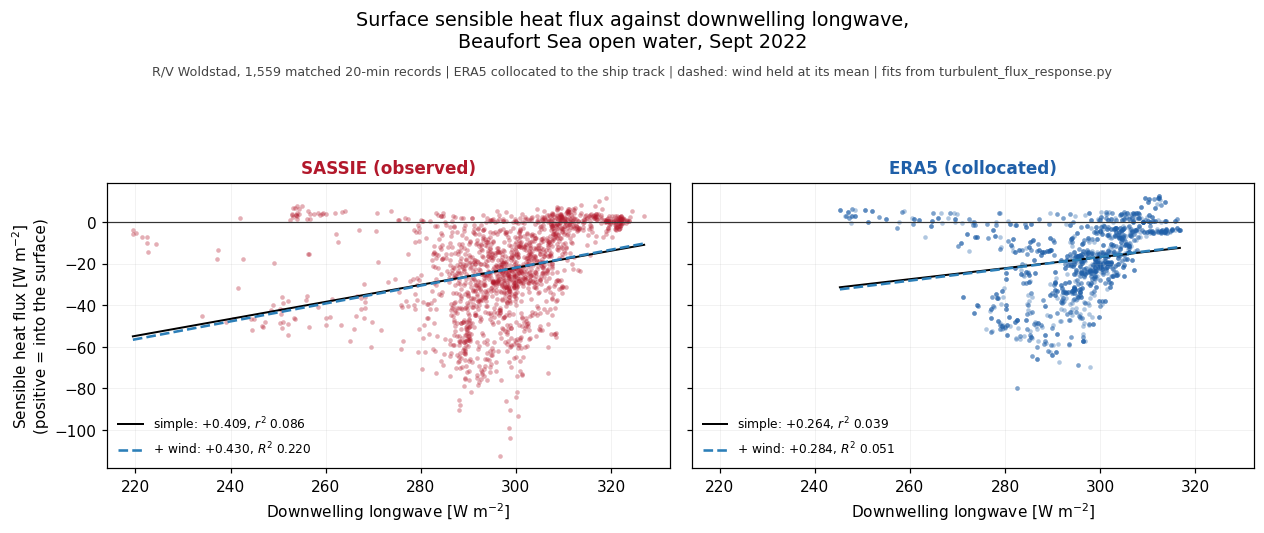

In [10]:
def scatter_compare(flux, flux_label, fname):
    '''SASSIE vs collocated ERA5 for one flux, fitted with the module.'''
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.9), sharex=True, sharey=True)
    panels = (("SASSIE (observed)", acc_obs, "", "#B2182B"),
              ("ERA5 (collocated)", acc_era5, "e_", "#1f5fa8"))

    for ax, (label, acc, pre, colour) in zip(axes, panels):
        x, y = d[pre + "lwd_W_m2"], d[pre + flux]
        ax.scatter(x, y, s=9, alpha=0.35, color=colour, linewidths=0)
        xs = np.array([x.min(), x.max()])

        simple = tfr.moment_stats(acc, 0, "lwd_W_m2", flux, weighted=False)
        ax.plot(xs, simple["intercept"] + simple["slope"] * xs,
                color="black", lw=1.3,
                label=f"simple: {simple['slope']:+.3f}, "
                      f"$r^2$ {simple['r2']:.3f}")

        mult = tfr.multiple_stats(acc, 0, flux, ("lwd_W_m2", "wspd_m_s"),
                                  weighted=False)
        u_bar = tfr.mean_of(acc, 0, "wspd_m_s")
        ax.plot(xs, mult["intercept"] + mult["coef"][0] * xs
                + mult["coef"][1] * u_bar,
                color="#2c7fb8", lw=1.7, ls="--",
                label=f"+ wind: {mult['coef'][0]:+.3f}, "
                      f"$R^2$ {mult['r2']:.3f}")

        ax.axhline(0, color="#333333", lw=0.8)
        ax.set_title(label, fontsize=11, fontweight="bold", color=colour)
        ax.set_xlabel("Downwelling longwave [W m$^{-2}$]")
        ax.legend(fontsize=8, frameon=False, loc="lower left")
        ax.grid(alpha=0.2, lw=0.5)

    axes[0].set_ylabel(f"{flux_label} heat flux [W m$^{{-2}}$]\n"
                       "(positive = into the surface)")
    fig.suptitle(f"Surface {flux_label.lower()} heat flux against downwelling "
                 "longwave,\nBeaufort Sea open water, Sept 2022", fontsize=12.5)
    fig.text(0.5, 0.86, f"R/V Woldstad, {len(d):,} matched 20-min records | "
             "ERA5 collocated to the ship track | dashed: wind held at its mean "
             "| fits from turbulent_flux_response.py",
             ha="center", fontsize=8.3, color="#444444")
    fig.tight_layout(rect=(0, 0, 1, 0.84))
    fig.savefig(SAVE_DIR / fname, dpi=DPI, bbox_inches="tight")
    return fig

scatter_compare("shf_W_m2", "Sensible", "sassie_vs_era5_shf_dlr.png");

### The same comparison for the latent heat flux

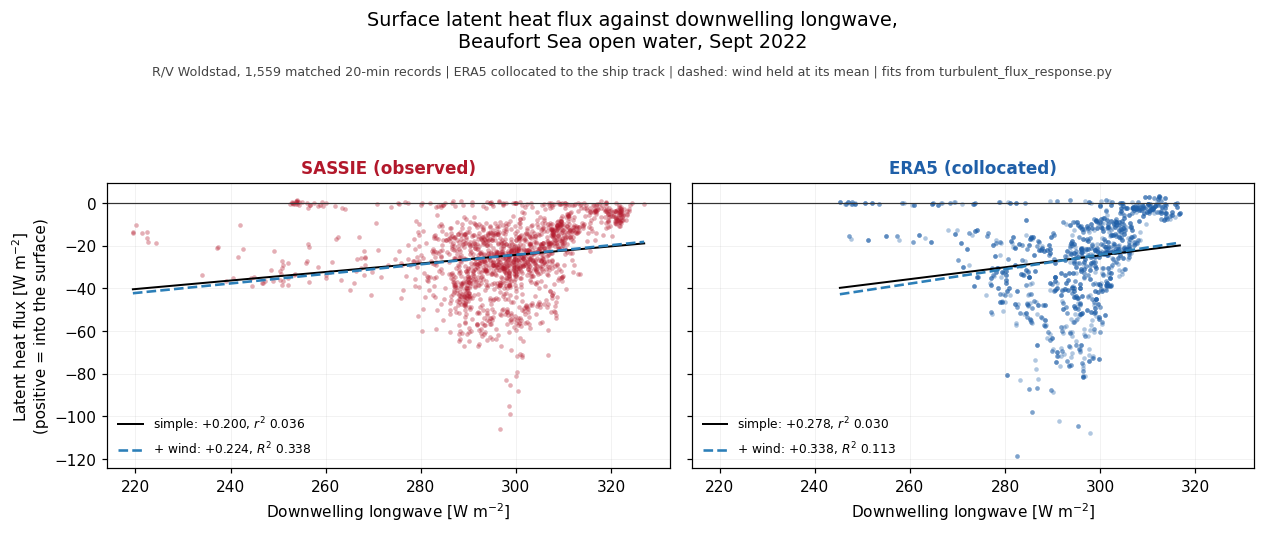

In [11]:
scatter_compare("lhf_W_m2", "Latent", "sassie_vs_era5_lhf_dlr.png");

## 5. Does the surface actually respond?

This is the test the notebook exists for. The companion notebook argues ERA5's
open-water skin temperature cannot respond hourly because it is prescribed. The
SASSIE record has a **measured** sea surface temperature in the same water at
the same time, so the two can be compared directly.

Two diagnostics: how much the surface temperature moves between consecutive
records, and how strongly it tracks DLR — the latter from the module's own
estimator, so it is the same quantity figure 4 of the companion notebook plots.

In [10]:
print(f"{'':<26}{'mean':>9}{'sd':>7}{'sd(20-min step)':>18}"
      f"{'dT/dDLR':>11}{'r2':>7}")
for label, acc, col in (("SASSIE SST (measured)", acc_obs, "skt_K"),
                        ("ERA5 skt (prescribed)", acc_era5, "e_skt_K")):
    x = d[col].values
    st = tfr.moment_stats(acc, 0, "lwd_W_m2", "skt_K", weighted=False)
    print(f"{label:<26}{x.mean():>9.2f}{x.std():>7.2f}"
          f"{np.diff(x).std():>18.4f}{st['slope']:>11.5f}{st['r2']:>7.3f}")

s_o = tfr.moment_stats(acc_obs, 0, "lwd_W_m2", "skt_K", weighted=False)["slope"]
s_e = tfr.moment_stats(acc_era5, 0, "lwd_W_m2", "skt_K", weighted=False)["slope"]
print(f"\nobserved SST moves "
      f"{np.diff(d.skt_K.values).std() / np.diff(d.e_skt_K.values).std():.1f}x "
      f"more per 20 min than ERA5's, and its DLR sensitivity is "
      f"{s_o / s_e:.1f}x larger.")
print("Both are small in absolute terms: the ocean's heat capacity dominates in "
      "the measurements too.")

                               mean     sd   sd(20-min step)    dT/dDLR     r2
SASSIE SST (measured)        274.20   1.37            0.3475    0.01255  0.020
ERA5 skt (prescribed)        273.82   1.21            0.1272    0.00383  0.002

observed SST moves 2.7x more per 20 min than ERA5's, and its DLR sensitivity is 3.3x larger.
Both are small in absolute terms: the ocean's heat capacity dominates in the measurements too.


## 6. What this says

**The sign and the order of magnitude survive the comparison.** Both the
observations and ERA5 give a *positive* $d\mathrm{SHF}/d\mathrm{DLR}$ over open
water — more downwelling longwave goes with more heat entering the ocean
surface, not less. That is the same sign the companion notebook reports for the
Barrow-strip open-water class, and it is opposite to the naive damping
expectation, for the same reason: the surface barely moves, so the whole
skin-to-air difference is the air moving.

**The two errors run in opposite directions, and largely cancel.** ERA5
*understates* the sensible response and *overstates* the latent one:

| | SASSIE | ERA5 | ERA5 − obs |
|---|---|---|---|
| $d\mathrm{SHF}/d\mathrm{DLR}$ | +0.409 | +0.264 | **−35%** |
| $d\mathrm{LHF}/d\mathrm{DLR}$ | +0.200 | +0.278 | **+39%** |
| sum, $d(\mathrm{SH+LH})/d\mathrm{DLR}$ | +0.609 | +0.542 | −11% |

So ERA5 gets the **total** turbulent response to DLR roughly right while
getting the **partition between the two terms** wrong, in compensating
directions. A validation that looked only at the net turbulent flux would have
missed this; it is visible only because the two terms were estimated
separately. Whether the compensation is coincidence or a constraint of the
bulk scheme is not something 23 days can answer.

**Both fluxes respond in the same direction here**, which is worth noting
because over the Barrow strip as a whole they had opposite signs. Over open
water in early autumn both terms carry heat out of a surface warmer and moister
than the air, and both respond to DLR positively.

**Wind matters more for the latent term.** Adding $U_{10}$ raises the observed
$R^2$ from 0.04 to 0.34 for latent, against 0.09 to 0.22 for sensible, and it
is the only specification in which the observed latent slope clears zero. That
is the bulk formula asserting itself: the moisture difference is smaller and
noisier than the temperature difference, so the exchange velocity carries more
of the signal.

**The confidence intervals are wide, and honestly so.** The cruise is 23 days.
At 24-hour blocks that is about twenty independent samples, and probably fewer
independent *synoptic situations* than that. Read the comparison as "the
observations and ERA5 are consistent with each other and both are consistent
with a positive slope", not as a detected discrepancy.

Note the contrast in how wrong the naive standard error is: about **6×** too
small here, against roughly **140×** in the gridded ERA5 analysis. A ship is one
point, so only time is redundant; a 2,501-cell domain is redundant in space as
well.

**On the prescribed-SST argument — partial support, and a needed correction.**
The measured SST does move more than ERA5's and tracks DLR several times more
strongly, which supports the claim that ERA5's prescribed ocean surface is
under-responsive. But **both** sensitivities are small and both $r^2$ are near
zero. The real ocean does not respond much to hourly DLR either — its heat
capacity is genuinely enormous.

So the near-zero open-water $dT_{skin}/d\mathrm{DLR}$ in ERA5 is *part* model
artefact and *part* real physics, and the companion notebook's framing —
which leant on the model artefact — needs that qualification.

Two caveats on the surface-response diagnostic specifically. The ship is
**moving**, so a 20-minute change in measured SST mixes temporal evolution with
the ship steaming into different water; ERA5 on a 0.25° grid smooths exactly
that structure away. And a bulk SST from a hull sensor is not the radiative skin
temperature ERA5 reports. Both push the comparison in the same direction, so
treat the ratio as an upper bound on ERA5's under-responsiveness rather than a
measurement of it.